# Phase 11 (Bonus) — Robustness: Drift + Noise (E6), Drift + Missing Data (E7) và chọn biến thích nghi tự động

Ba câu hỏi:
1. **E6:** khi cảm biến có nhiễu Gaussian, ADWIN còn phát hiện đúng không, và Evolving còn giảm được FPR không?
2. **E7:** khi một phần giá trị cảm biến bị mất (MCAR) và được điền bằng LOCF (chỉ dùng quá khứ), hệ thống hành xử thế nào?
3. **Auto variable selection:** Phase 6/7 *biết trước* drift nằm ở RPM và Torque (một dạng oracle). Nếu hệ thống tự chọn biến cần dịch, chỉ dựa trên buffer không nhãn, kết quả thay đổi ra sao?

Mỗi cấu hình chạy 5 seed. Báo cáo mean ± std. τ = 0.67, W = 200, ADWIN δ = 0.002, đều giữ nguyên.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import (load_dataset, make_scenarios, train_sensor_std, train_sensor_median,
                      add_gaussian_noise, inject_missing, impute_locf, SUDDEN_DRIFT_POINT, GRADUAL_DRIFT_START, GRADUAL_DRIFT_END)
from src.evolving import PrequentialRunner
from src.drift import FixedDetections
from src.evaluation import evaluate
df = load_dataset(); scenarios = make_scenarios(df)
REF_STD = train_sensor_std(df); REF_MED = train_sensor_median(df)
ONSET = {"Control": None, "Sudden Drift": SUDDEN_DRIFT_POINT, "Gradual Drift": GRADUAL_DRIFT_START}
SEEDS = [0, 1, 2, 3, 4]
print("Train std:", {k: round(v, 3) for k, v in REF_STD.items()})

def run_pair(stream, scen, adapt_vars=("rpm", "torque"), auto_k=0.5):
    out = {}
    for model in ["Static", "Evolving"]:
        r = PrequentialRunner(evolve=(model == "Evolving"), adapt_vars=adapt_vars, ref_std=REF_STD, auto_k=auto_k)
        log = r.run(stream)
        m = evaluate(log.label, log.score)
        det = [e["t"] for e in r.events if e["event"] == "drift_detected"]
        ad = [e for e in r.events if e["event"] == "adapted"]
        onset = ONSET[scen]
        out[model] = {**m, "detections": det, "n_det": len(det),
                      "false_alarm_before_onset": sum(d < onset for d in det) if onset is not None else len(det),
                      "first_det_after_onset": next((d for d in det if onset is not None and d >= onset), None),
                      "adapted_vars": ad[0]["variables"] if ad else [], "shifts": ad[0]["shifts"] if ad else {}}
    return out

Train std: {'air_temp': 2.283, 'process_temp': 1.665, 'rpm': 182.909, 'torque': 9.977, 'tool_wear': 63.976}


## 11.1 — E6: Drift + Noise

Nhiễu $\mathcal{N}(0, (\sigma_{frac}\cdot \text{std}_{train})^2)$ cộng vào **cả 5 cảm biến**, sau đó clip theo miền vật lý. $\sigma_{frac} \in \{0.05, 0.1, 0.2, 0.3\}$.

In [2]:
rows = []
for frac in [0.05, 0.1, 0.2, 0.3]:
    for scen, base in scenarios.items():
        for seed in SEEDS:
            s = add_gaussian_noise(base, frac, REF_STD, seed=seed)
            res = run_pair(s, scen)
            for model, m in res.items():
                rows.append({"noise_frac": frac, "Scenario": scen, "seed": seed, "Model": model,
                             **{k: m[k] for k in ["TP", "FP", "FN", "Precision", "Recall", "F1", "FPR", "n_det",
                                                  "false_alarm_before_onset", "first_det_after_onset"]}})
noise_df = pd.DataFrame(rows)
agg = (noise_df.groupby(["noise_frac", "Scenario", "Model"])
       .agg(F1=("F1", "mean"), F1_sd=("F1", "std"), FPR=("FPR", "mean"), FPR_sd=("FPR", "std"),
            Recall=("Recall", "mean"), n_det=("n_det", "mean"), false_alarms=("false_alarm_before_onset", "mean"),
            first_det=("first_det_after_onset", "mean")).round(4))
agg

F1   F1_sd     FPR  FPR_sd  Recall  \
noise_frac Scenario      Model                                              
0.05       Control       Evolving  0.3025  0.0082  0.0173  0.0012  0.3333   
                         Static    0.3025  0.0082  0.0173  0.0012  0.3333   
           Gradual Drift Evolving  0.2514  0.0202  0.0312  0.0012  0.3692   
                         Static    0.2191  0.0068  0.0572  0.0007  0.4769   
           Sudden Drift  Evolving  0.2747  0.0170  0.0281  0.0012  0.3846   
                         Static    0.2173  0.0076  0.0579  0.0011  0.4769   
0.10       Control       Evolving  0.3022  0.0252  0.0173  0.0012  0.3333   
                         Static    0.3022  0.0252  0.0173  0.0012  0.3333   
           Gradual Drift Evolving  0.2441  0.0152  0.0322  0.0018  0.3641   
                         Static    0.2235  0.0059  0.0579  0.0007  0.4923   
           Sudden Drift  Evolving  0.2662  0.0265  0.0279  0.0019  0.3692   
                         Static    0.2207  0.0036  0.0582  0.0014  0.4872   
0.20       Control       Evolving  0.2774  0.0253  0.0189  0.0025  0.3128   
                         Static    0.2774  0.0253  0.0189  0.0025  0.3128   
           Gradual Drift Evolving  0.2356  0.0132  0.0327  0.0029  0.3538   
                         Static    0.2279  0.0126  0.0563  0.0027  0.4923   
           Sudden Drift  Evolving  0.2567  0.0231  0.0279  0.0026  0.3538   
                         Static    0.2272  0.0103  0.0566  0.0027  0.4923   
0.30       Control       Evolving  0.2416  0.0113  0.0195  0.0018  0.2718   
                         Static    0.2416  0.0113  0.0195  0.0018  0.2718   
           Gradual Drift Evolving  0.2221  0.0155  0.0332  0.0023  0.3333   
                         Static    0.2266  0.0184  0.0552  0.0025  0.4821   
           Sudden Drift  Evolving  0.2313  0.0154  0.0293  0.0020  0.3231   
                         Static    0.2227  0.0193  0.0559  0.0026  0.4769   

                                   n_det  false_alarms  first_det  
noise_frac Scenario      Model                                     
0.05       Control       Evolving    0.0           0.0        NaN  
                         Static      0.0           0.0        NaN  
           Gradual Drift Evolving    1.0           0.0     1253.4  
                         Static      1.0           0.0     1253.4  
           Sudden Drift  Evolving    1.0           0.0     1183.0  
                         Static      1.0           0.0     1183.0  
0.10       Control       Evolving    0.0           0.0        NaN  
                         Static      0.0           0.0        NaN  
           Gradual Drift Evolving    1.0           0.0     1272.6  
                         Static      1.0           0.0     1272.6  
           Sudden Drift  Evolving    1.0           0.0     1183.0  
                         Static      1.0           0.0     1183.0  
0.20       Control       Evolving    0.0           0.0        NaN  
                         Static      0.0           0.0        NaN  
           Gradual Drift Evolving    1.0           0.0     1285.4  
                         Static      1.0           0.0     1285.4  
           Sudden Drift  Evolving    1.0           0.0     1183.0  
                         Static      1.0           0.0     1183.0  
0.30       Control       Evolving    0.0           0.0        NaN  
                         Static      0.0           0.0        NaN  
           Gradual Drift Evolving    1.0           0.0     1311.0  
                         Static      1.0           0.0     1311.0  
           Sudden Drift  Evolving    1.0           0.0     1195.8  
                         Static      1.0           0.0     1195.8

Evolving tốt hơn Static trên bao nhiêu seed (theo FPR và F1)?

In [3]:
piv = noise_df.pivot_table(index=["noise_frac", "Scenario", "seed"], columns="Model", values=["F1", "FPR", "Recall"])
win = pd.DataFrame({
    "FPR_lower_evolving": (piv[("FPR", "Evolving")] < piv[("FPR", "Static")]),
    "FPR_equal": (piv[("FPR", "Evolving")] == piv[("FPR", "Static")]),
    "F1_higher_evolving": (piv[("F1", "Evolving")] > piv[("F1", "Static")]),
    "Recall_lower_evolving": (piv[("Recall", "Evolving")] < piv[("Recall", "Static")]),
}).groupby(level=[0, 1]).sum()
win

FPR_lower_evolving  FPR_equal  F1_higher_evolving  \
noise_frac Scenario                                                           
0.05       Control                         0          5                   0   
           Gradual Drift                   5          0                   5   
           Sudden Drift                    5          0                   5   
0.10       Control                         0          5                   0   
           Gradual Drift                   5          0                   5   
           Sudden Drift                    5          0                   5   
0.20       Control                         0          5                   0   
           Gradual Drift                   5          0                   5   
           Sudden Drift                    5          0                   4   
0.30       Control                         0          5                   0   
           Gradual Drift                   5          0                   3   
           Sudden Drift                    5          0                   4   

                          Recall_lower_evolving  
noise_frac Scenario                              
0.05       Control                            0  
           Gradual Drift                      5  
           Sudden Drift                       5  
0.10       Control                            0  
           Gradual Drift                      5  
           Sudden Drift                       5  
0.20       Control                            0  
           Gradual Drift                      5  
           Sudden Drift                       5  
0.30       Control                            0  
           Gradual Drift                      5  
           Sudden Drift                       5

## 11.2 — E7: Drift + Missing Data

Mỗi giá trị cảm biến bị mất độc lập với xác suất $p \in \{0.05, 0.1, 0.2\}$ (MCAR), rồi điền bằng **LOCF**: lấy giá trị hợp lệ gần nhất *trong quá khứ*, không nhìn tương lai. Nếu mất ngay đầu luồng thì điền bằng median của tập Train. Nhãn giữ nguyên.

In [4]:
rows = []
for rate in [0.05, 0.1, 0.2]:
    for scen, base in scenarios.items():
        for seed in SEEDS:
            s = impute_locf(inject_missing(base, rate, seed=seed), REF_MED)
            assert not s[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]].isna().any().any()
            res = run_pair(s, scen)
            for model, m in res.items():
                rows.append({"missing_rate": rate, "Scenario": scen, "seed": seed, "Model": model,
                             **{k: m[k] for k in ["TP", "FP", "FN", "Precision", "Recall", "F1", "FPR", "n_det",
                                                  "false_alarm_before_onset", "first_det_after_onset"]}})
miss_df = pd.DataFrame(rows)
agg_m = (miss_df.groupby(["missing_rate", "Scenario", "Model"])
         .agg(F1=("F1", "mean"), F1_sd=("F1", "std"), FPR=("FPR", "mean"), FPR_sd=("FPR", "std"),
              Recall=("Recall", "mean"), n_det=("n_det", "mean"), false_alarms=("false_alarm_before_onset", "mean"),
              first_det=("first_det_after_onset", "mean")).round(4))
agg_m

F1   F1_sd     FPR  FPR_sd  Recall  \
missing_rate Scenario      Model                                              
0.05         Control       Evolving  0.2863  0.0255  0.0155  0.0011  0.2974   
                           Static    0.2863  0.0255  0.0155  0.0011  0.2974   
             Gradual Drift Evolving  0.2442  0.0051  0.0300  0.0019  0.3487   
                           Static    0.2120  0.0111  0.0541  0.0008  0.4410   
             Sudden Drift  Evolving  0.2612  0.0129  0.0263  0.0011  0.3487   
                           Static    0.2107  0.0105  0.0546  0.0010  0.4410   
0.10         Control       Evolving  0.2741  0.0286  0.0142  0.0018  0.2718   
                           Static    0.2741  0.0286  0.0142  0.0018  0.2718   
             Gradual Drift Evolving  0.2412  0.0147  0.0285  0.0021  0.3333   
                           Static    0.2151  0.0103  0.0512  0.0015  0.4308   
             Sudden Drift  Evolving  0.2542  0.0236  0.0243  0.0019  0.3231   
                           Static    0.2142  0.0085  0.0515  0.0008  0.4308   
0.20         Control       Evolving  0.2711  0.0346  0.0114  0.0022  0.2462   
                           Static    0.2711  0.0346  0.0114  0.0022  0.2462   
             Gradual Drift Evolving  0.2397  0.0515  0.0253  0.0041  0.3077   
                           Static    0.2204  0.0116  0.0468  0.0031  0.4154   
             Sudden Drift  Evolving  0.2591  0.0276  0.0219  0.0027  0.3128   
                           Static    0.2186  0.0093  0.0474  0.0028  0.4154   

                                     n_det  false_alarms  first_det  
missing_rate Scenario      Model                                     
0.05         Control       Evolving    0.0           0.0        NaN  
                           Static      0.0           0.0        NaN  
             Gradual Drift Evolving    1.0           0.0     1259.8  
                           Static      1.0           0.0     1259.8  
             Sudden Drift  Evolving    1.0           0.0     1183.0  
                           Static      1.0           0.0     1183.0  
0.10         Control       Evolving    0.0           0.0        NaN  
                           Static      0.0           0.0        NaN  
             Gradual Drift Evolving    1.0           0.0     1272.6  
                           Static      1.0           0.0     1272.6  
             Sudden Drift  Evolving    1.0           0.0     1183.0  
                           Static      1.0           0.0     1183.0  
0.20         Control       Evolving    0.0           0.0        NaN  
                           Static      0.0           0.0        NaN  
             Gradual Drift Evolving    1.0           0.0     1272.6  
                           Static      1.0           0.0     1272.6  
             Sudden Drift  Evolving    1.0           0.0     1176.6  
                           Static      1.0           0.0     1176.6

## 11.3 — Bỏ oracle "drift nằm ở RPM/Torque": chọn biến tự động và điểm tham chiếu

Hai lựa chọn thiết kế được thử:
- **Chọn biến:** `oracle` = RPM + Torque như Phase 7, hoặc `auto` = chỉ dịch biến có $z_v = |\bar{x}_{buffer,v} - \text{ref}_v| / \text{std}_{train,v} > k$.
- **Điểm tham chiếu:** `design` = tâm MF MEDIUM như Phase 7, hoặc `warmup` = trung bình 500 mẫu **đầu luồng, không nhãn**. Giả định của `warmup`: máy được đưa vào vận hành ở trạng thái bình thường. Giả định này không dùng mốc tiêm drift.

Tất cả chạy trên dữ liệu sạch, không nhiễu, không missing.

In [5]:
rows = []
for ref in ["design", "warmup"]:
    for sel, k in [("oracle", None), ("auto", 0.3), ("auto", 0.5), ("auto", 1.0)]:
        for scen, base in scenarios.items():
            r = PrequentialRunner(evolve=True, adapt_vars=("rpm", "torque") if sel == "oracle" else "auto",
                                  ref_std=REF_STD, auto_k=k or 0.5, reference=ref)
            log = r.run(base); m = evaluate(log.label, log.score)
            ad = [e for e in r.events if e["event"] == "adapted"]
            rows.append({"reference": ref, "selection": sel if sel == "oracle" else f"auto k={k}", "Scenario": scen,
                         "adapted_vars": ",".join(ad[0]["variables"]) if ad else "—",
                         "z": {v: round(z, 2) for v, z in ad[0]["z"].items()} if ad and ad[0]["z"] else "",
                         "shifts": {v: round(x, 2) for v, x in ad[0]["shifts"].items()} if ad else "",
                         "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "F1": round(m["F1"], 4), "FPR": round(m["FPR"], 4)})
auto_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 120)
auto_df

,reference,selection,Scenario,adapted_vars,z,shifts,TP,FP,FN,F1,FPR
0,design,oracle,Control,—,,,13,34,26,0.3023,0.0173
1,design,oracle,Sudden Drift,"rpm,torque",,"{'rpm': -156.21, 'torque': 7.3}",15,56,24,0.2727,0.0286
2,design,oracle,Gradual Drift,"rpm,torque",,"{'rpm': -161.96, 'torque': 8.05}",14,61,25,0.2456,0.0311
3,design,auto k=0.3,Control,—,,,13,34,26,0.3023,0.0173
4,design,auto k=0.3,Sudden Drift,"air_temp,process_temp,rpm,torque","{'air_temp': 0.95, 'process_temp': 0.5, 'rpm': 0.85, 'torque': 0.73, 'tool_wear': 0.17}","{'air_temp': -2.17, 'process_temp': -0.84, 'rpm': -156.21, 'torque': 7.3}",15,60,24,0.2632,0.0306
5,design,auto k=0.3,Gradual Drift,"air_temp,process_temp,rpm,torque","{'air_temp': 0.96, 'process_temp': 0.59, 'rpm': 0.89, 'torque': 0.81, 'tool_wear': 0.14}","{'air_temp': -2.19, 'process_temp': -0.99, 'rpm': -161.96, 'torque': 8.05}",14,68,25,0.2314,0.0347
6,design,auto k=0.5,Control,—,,,13,34,26,0.3023,0.0173
7,design,auto k=0.5,Sudden Drift,"air_temp,process_temp,rpm,torque","{'air_temp': 0.95, 'process_temp': 0.5, 'rpm': 0.85, 'torque': 0.73, 'tool_wear': 0.17}","{'air_temp': -2.17, 'process_temp': -0.84, 'rpm': -156.21, 'torque': 7.3}",15,60,24,0.2632,0.0306
8,design,auto k=0.5,Gradual Drift,"air_temp,process_temp,rpm,torque","{'air_temp': 0.96, 'process_temp': 0.59, 'rpm': 0.89, 'torque': 0.81, 'tool_wear': 0.14}","{'air_temp': -2.19, 'process_temp': -0.99, 'rpm': -161.96, 'torque': 8.05}",14,68,25,0.2314,0.0347
9,design,auto k=1.0,Control,—,,,13,34,26,0.3023,0.0173


## 11.3b — Stress test báo động nhầm trên Control: `design` so với `warmup`

In [6]:
rows = []
for ref in ["design", "warmup"]:
    for sel in ["oracle", "auto"]:
        for t_false in [300, 700, 1000, 1400]:
            r = PrequentialRunner(evolve=True, adapt_vars=("rpm", "torque") if sel == "oracle" else "auto", ref_std=REF_STD,
                                  auto_k=0.5, reference=ref, detector=FixedDetections([t_false]))
            log = r.run(scenarios["Control"]); m = evaluate(log.label, log.score)
            ad = [e for e in r.events if e["event"] == "adapted"][0]
            rows.append({"reference": ref, "selection": sel, "false_alarm_t": t_false,
                         "shifts": {v: round(x, 2) for v, x in ad["shifts"].items()},
                         "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "F1": round(m["F1"], 4)})
stress2 = pd.DataFrame(rows)
print("E1 (no adaptation): TP=13 FP=34 FN=26 F1=0.3023")
print(stress2.groupby(["reference", "selection"])[["TP", "FP", "F1"]].mean().round(3))
stress2

E1 (no adaptation): TP=13 FP=34 FN=26 F1=0.3023
                        TP     FP     F1
reference selection                     
design    auto       13.50  39.50  0.294
          oracle      9.75  31.00  0.242
warmup    auto       14.00  48.25  0.279
          oracle     11.75  33.50  0.277


,reference,selection,false_alarm_t,shifts,TP,FP,FN,F1
0,design,oracle,300,"{'rpm': -32.56, 'torque': 1.05}",8,27,31,0.2162
1,design,oracle,700,"{'rpm': -33.29, 'torque': 0.35}",8,29,31,0.2105
2,design,oracle,1000,"{'rpm': 2.09, 'torque': -0.97}",13,36,26,0.2955
3,design,oracle,1400,"{'rpm': -21.0, 'torque': 0.69}",10,32,29,0.2469
4,design,auto,300,{'air_temp': -1.63},13,34,26,0.3023
5,design,auto,700,"{'air_temp': -2.84, 'process_temp': -1.0}",14,41,25,0.2979
6,design,auto,1000,"{'air_temp': -2.85, 'process_temp': -1.31}",14,49,25,0.2745
7,design,auto,1400,{'air_temp': -1.44},13,34,26,0.3023
8,warmup,oracle,300,"{'rpm': -16.29, 'torque': 1.12}",10,29,29,0.2564
9,warmup,oracle,700,"{'rpm': -17.02, 'torque': 0.42}",10,31,29,0.2500


## 11.4 — Hình

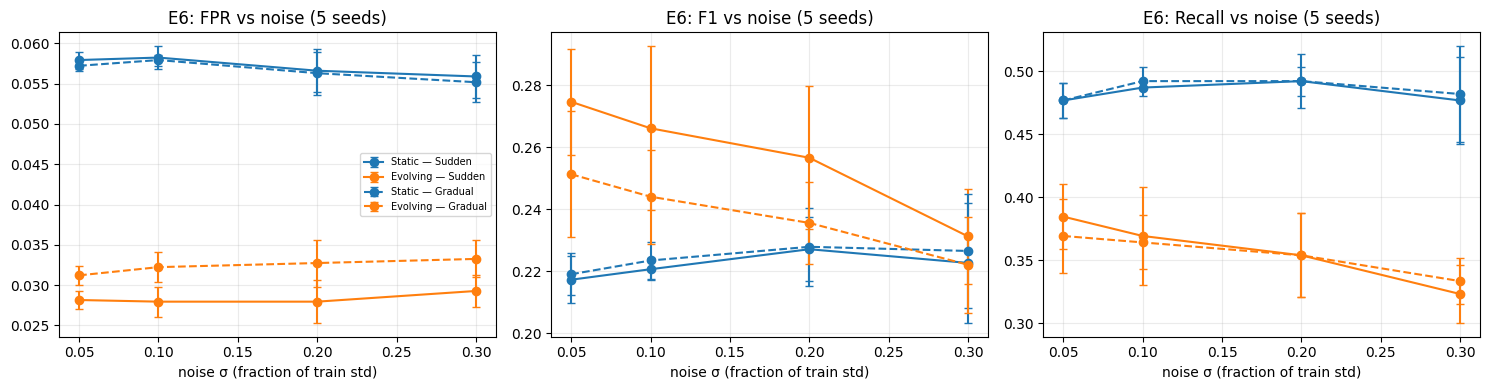

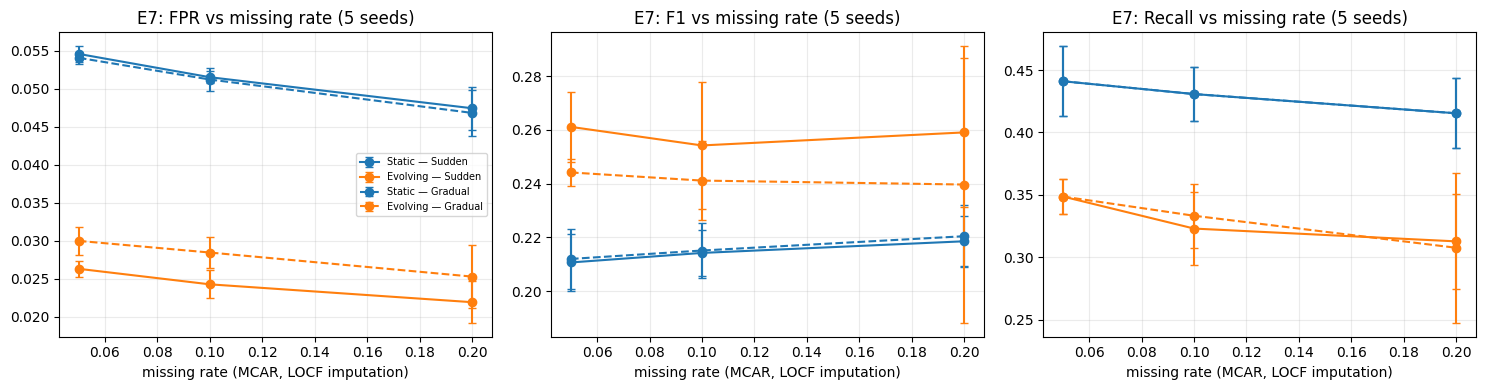

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (met, lab) in zip(axes, [("FPR", "FPR"), ("F1", "F1"), ("Recall", "Recall")]):
    for scen, ls in [("Sudden Drift", "-"), ("Gradual Drift", "--")]:
        for model, c in [("Static", "tab:blue"), ("Evolving", "tab:orange")]:
            d = noise_df[(noise_df.Scenario == scen) & (noise_df.Model == model)].groupby("noise_frac")[met]
            ax.errorbar(d.mean().index, d.mean().values, yerr=d.std().values, ls=ls, color=c, marker="o", capsize=3, label=f"{model} — {scen.split()[0]}")
    ax.set_xlabel("noise σ (fraction of train std)"); ax.set_title(f"E6: {lab} vs noise (5 seeds)"); ax.grid(alpha=.25)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(ROOT / "figures" / "11_noise_robustness.png", dpi=130); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, met in zip(axes, ["FPR", "F1", "Recall"]):
    for scen, ls in [("Sudden Drift", "-"), ("Gradual Drift", "--")]:
        for model, c in [("Static", "tab:blue"), ("Evolving", "tab:orange")]:
            d = miss_df[(miss_df.Scenario == scen) & (miss_df.Model == model)].groupby("missing_rate")[met]
            ax.errorbar(d.mean().index, d.mean().values, yerr=d.std().values, ls=ls, color=c, marker="o", capsize=3, label=f"{model} — {scen.split()[0]}")
    ax.set_xlabel("missing rate (MCAR, LOCF imputation)"); ax.set_title(f"E7: {met} vs missing rate (5 seeds)"); ax.grid(alpha=.25)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(ROOT / "figures" / "11_missing_robustness.png", dpi=130); plt.show()

In [8]:
noise_df.to_csv(ROOT / "results" / "11_noise_runs.csv", index=False)
miss_df.to_csv(ROOT / "results" / "11_missing_runs.csv", index=False)
agg.to_csv(ROOT / "results" / "11_noise_summary.csv"); agg_m.to_csv(ROOT / "results" / "11_missing_summary.csv")
win.to_csv(ROOT / "results" / "11_noise_win_counts.csv"); auto_df.to_csv(ROOT / "results" / "11_auto_variable_selection.csv", index=False)
stress2.to_csv(ROOT / "results" / "11_false_alarm_stress_reference.csv", index=False)
print("Phase 11: COMPLETE")

Phase 11: COMPLETE
